# EVE single-neuron microscope — publication reproducibility notebook

This notebook contains the controlled experimental package for the paper:

> **Variational Neurons and Bayesian Neural Networks: Distinct Probabilistic Objects, Inference Loci, and Computational Granularity**

It compares four neuron-level primitives:

1. **DET-scalar** — deterministic scalar neuron.
2. **STOCH-hetero** — output-heteroscedastic stochastic comparator with learned input-dependent Gaussian variance, no local latent state, no local reference distribution, and no local KL.
3. **DET-cell matched** — deterministic capacity-matched cell with internal encoder/decoder MLPs comparable to EVE, but no latent sampling and no local KL.
4. **EVE k=2 (EVE-reg)** — input-conditioned local Gaussian latent distribution, standard-normal local reference distribution, local KL regularization, decoded activation, and unit-indexed diagnostics; no strict local posterior inference is claimed.

The main probe is heteroscedastic regression. A bimodal generator is retained only as an optional stress-test generator and is not used for the main reported comparison.


In [1]:

# ============================================================
# 0. Setup and run configuration
# ============================================================
import os
import math
import copy
import json
import time
import zipfile
import random
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from IPython.display import display
except Exception:
    display = print

# ----------------------------
# Main run switches
# ----------------------------
# Final paper run: FAST_MODE=False and N_SEEDS=5.
# Quick debug run: FAST_MODE=True and N_SEEDS=1.
FAST_MODE = False
N_SEEDS = 5
SEEDS = list(range(N_SEEDS))

# Clean output folder at the beginning to avoid stale files in the zip.
CLEAR_OUTPUT_DIR = True

# ----------------------------
# Device
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ----------------------------
# Output directory
# ----------------------------
if Path("/kaggle/working").exists():
    OUT_DIR = Path("/kaggle/working/eve_single_neuron_outputs_publication")
elif Path("/content").exists():
    OUT_DIR = Path("/content/eve_single_neuron_outputs_publication")
else:
    OUT_DIR = Path("./eve_single_neuron_outputs_publication")

if CLEAR_OUTPUT_DIR and OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
DATA_DIR = OUT_DIR / "data"
PRED_DIR = OUT_DIR / "predictions"
MODEL_DIR = OUT_DIR / "models"
DIAG_DIR = OUT_DIR / "diagnostics"
HIST_DIR = OUT_DIR / "histories"

for d in [OUT_DIR, FIG_DIR, TABLE_DIR, DATA_DIR, PRED_DIR, MODEL_DIR, DIAG_DIR, HIST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUT_DIR.resolve())

# ----------------------------
# Runtime settings
# ----------------------------
if FAST_MODE:
    N_TRAIN = 1200
    N_VAL = 400
    N_TEST = 800
    EPOCHS_MAIN = 650
    EPOCHS_GRID = 350
    EPOCHS_MLP = 450
    MC_TRAIN = 16
    MC_EVAL = 96
    TIMING_REPEATS = 8
else:
    N_TRAIN = 2500
    N_VAL = 900
    N_TEST = 1500
    EPOCHS_MAIN = 1200
    EPOCHS_GRID = 500
    EPOCHS_MLP = 500
    MC_TRAIN = 32
    MC_EVAL = 160
    TIMING_REPEATS = 10

LR = 2e-3
PRINT_EVERY = 300 if not FAST_MODE else 150

RUN_CONTROL_GRID = True
RUN_PYTORCH_INTEGRATION = True
RUN_COMPUTE_COST = True
RUN_BIMODAL_STRESS = False  # Optional appendix-only stress probe; not used for the main claim.

CONFIG = {
    "FAST_MODE": FAST_MODE,
    "N_SEEDS": N_SEEDS,
    "SEEDS": SEEDS,
    "N_TRAIN": N_TRAIN,
    "N_VAL": N_VAL,
    "N_TEST": N_TEST,
    "EPOCHS_MAIN": EPOCHS_MAIN,
    "EPOCHS_GRID": EPOCHS_GRID,
    "EPOCHS_MLP": EPOCHS_MLP,
    "MC_TRAIN": MC_TRAIN,
    "MC_EVAL": MC_EVAL,
    "LR": LR,
    "DEVICE": str(DEVICE),
    "MAIN_PROBE": "heteroscedastic regression with input-dependent Gaussian noise",
    "STOCH_DEFINITION": "learned input-dependent Gaussian output variance; no local latent state, no local reference distribution, no local KL",
    "CAPACITY_BASELINE": "DET-cell matched with deterministic encoder/decoder MLPs comparable to EVE",
    "RUN_BIMODAL_STRESS": RUN_BIMODAL_STRESS,
}
print(json.dumps(CONFIG, indent=2))

with open(OUT_DIR / "run_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)


def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Device: cuda
Output directory: /content/eve_single_neuron_outputs_publication
{
  "FAST_MODE": false,
  "N_SEEDS": 5,
  "SEEDS": [
    0,
    1,
    2,
    3,
    4
  ],
  "N_TRAIN": 2500,
  "N_VAL": 900,
  "N_TEST": 1500,
  "EPOCHS_MAIN": 1200,
  "EPOCHS_GRID": 500,
  "EPOCHS_MLP": 500,
  "MC_TRAIN": 32,
  "MC_EVAL": 160,
  "LR": 0.002,
  "DEVICE": "cuda",
  "MAIN_PROBE": "heteroscedastic regression with input-dependent Gaussian noise",
  "STOCH_DEFINITION": "learned input-dependent Gaussian output variance; no local latent state, no local reference distribution, no local KL",
  "CAPACITY_BASELINE": "DET-cell matched with deterministic encoder/decoder MLPs comparable to EVE",
  "RUN_BIMODAL_STRESS": false
}


## 1. Synthetic probe data

The dataset is intentionally synthetic. It is not intended as a broad benchmark; it is a controlled probe of neuron-level behavior.

The main probe is **heteroscedastic**:

- a smooth deterministic backbone;
- input-dependent Gaussian observation variability;
- known conditional mean and standard deviation.

This design tests input-dependent probabilistic behavior without requiring a multimodal output head. A bimodal generator is retained only as an optional stress test and is not used in the main reported comparison.


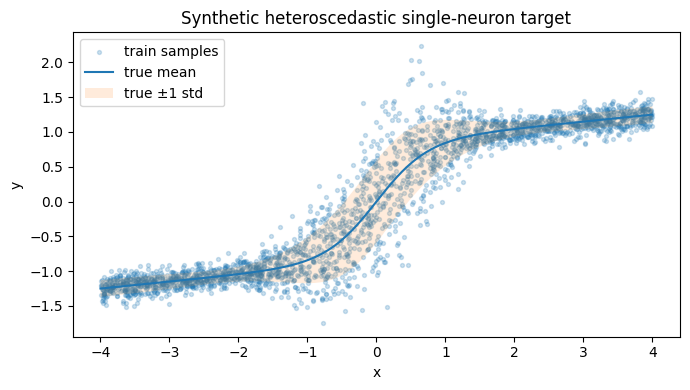

In [2]:

# ============================================================
# 1. Synthetic data
# ============================================================

def make_heteroscedastic_data(n: int, seed: int = 0, x_low: float = -4.0, x_high: float = 4.0) -> Dict[str, torch.Tensor]:
    """
    Main single-neuron regression probe.

    y | x is Gaussian with:
    - a smooth central tendency;
    - known input-dependent conditional standard deviation;
    - no bimodality in the main paper experiment.

    This controlled probe tests input-dependent observation variability
    without requiring a multimodal output head.
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_low, x_high, size=(n, 1)).astype(np.float32)

    # Smooth mean that a scalar tanh-like neuron can approximate reasonably.
    true_mean = (0.85 * np.tanh(1.35 * x) + 0.10 * x).astype(np.float32)

    # Known input-dependent observation variability. The Gaussian bump is the microscope region.
    uncertainty_gate = np.exp(-0.5 * (x / 0.85) ** 2).astype(np.float32)
    edge_gate = 1.0 / (1.0 + np.exp(-3.0 * (np.abs(x) - 2.7))).astype(np.float32)
    true_std = (0.07 + 0.52 * uncertainty_gate + 0.05 * edge_gate).astype(np.float32)

    y = true_mean + rng.normal(0.0, true_std).astype(np.float32)

    return {
        "x": torch.tensor(x, dtype=torch.float32),
        "y": torch.tensor(y, dtype=torch.float32),
        "true_mean": torch.tensor(true_mean, dtype=torch.float32),
        "true_std": torch.tensor(true_std, dtype=torch.float32),
        "ambiguity": torch.tensor(uncertainty_gate, dtype=torch.float32),
    }


def make_bimodal_stress_data(n: int, seed: int = 0, x_low: float = -4.0, x_high: float = 4.0) -> Dict[str, torch.Tensor]:
    """
    Optional appendix-only stress test.

    This creates a locally bimodal conditional target near x=0. It is deliberately
    not used as the main paper experiment because a Gaussian predictive head can
    mostly respond by inflating variance rather than representing two modes.
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_low, x_high, size=(n, 1)).astype(np.float32)
    true_mean = (0.85 * np.tanh(1.35 * x) + 0.10 * x).astype(np.float32)
    gate = np.exp(-0.5 * (x / 0.85) ** 2).astype(np.float32)
    branch = rng.choice([-1.0, 1.0], size=(n, 1)).astype(np.float32)
    branch_amp = 1.10
    obs_sigma = (0.06 + 0.05 * np.abs(x) / x_high + 0.18 * gate).astype(np.float32)
    y = true_mean + branch_amp * gate * branch + rng.normal(0.0, obs_sigma).astype(np.float32)
    true_std = np.sqrt((branch_amp * gate) ** 2 + obs_sigma ** 2).astype(np.float32)
    return {
        "x": torch.tensor(x, dtype=torch.float32),
        "y": torch.tensor(y, dtype=torch.float32),
        "true_mean": torch.tensor(true_mean, dtype=torch.float32),
        "true_std": torch.tensor(true_std, dtype=torch.float32),
        "ambiguity": torch.tensor(gate, dtype=torch.float32),
    }




def make_data_splits(seed: int) -> Dict[str, Dict[str, torch.Tensor]]:
    splits = {
        "train": make_heteroscedastic_data(N_TRAIN, seed=10_000 + seed * 10 + 1),
        "val": make_heteroscedastic_data(N_VAL, seed=10_000 + seed * 10 + 2),
        "test": make_heteroscedastic_data(N_TEST, seed=10_000 + seed * 10 + 3),
    }
    for split in splits.values():
        for k in split:
            split[k] = split[k].to(DEVICE)
    return splits


def true_functions_on_grid(x_grid: torch.Tensor) -> Dict[str, torch.Tensor]:
    true_mean = 0.85 * torch.tanh(1.35 * x_grid) + 0.10 * x_grid
    uncertainty_gate = torch.exp(-0.5 * (x_grid / 0.85) ** 2)
    edge_gate = torch.sigmoid(3.0 * (torch.abs(x_grid) - 2.7))
    true_std = 0.07 + 0.52 * uncertainty_gate + 0.05 * edge_gate
    return {"true_mean": true_mean, "true_std": true_std, "ambiguity": uncertainty_gate}

# Fixed grid used for figures and uncertainty tracking.
x_grid = torch.linspace(-4, 4, 600, device=DEVICE).view(-1, 1)
grid_truth = true_functions_on_grid(x_grid)

# Representative data for figures.
rep_splits = make_data_splits(SEEDS[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(rep_splits["train"]["x"].detach().cpu().numpy().ravel(),
           rep_splits["train"]["y"].detach().cpu().numpy().ravel(),
           s=8, alpha=0.22, label="train samples")
ax.plot(x_grid.detach().cpu().numpy().ravel(), grid_truth["true_mean"].detach().cpu().numpy().ravel(), label="true mean")
ax.fill_between(
    x_grid.detach().cpu().numpy().ravel(),
    (grid_truth["true_mean"] - grid_truth["true_std"]).detach().cpu().numpy().ravel(),
    (grid_truth["true_mean"] + grid_truth["true_std"]).detach().cpu().numpy().ravel(),
    alpha=0.15,
    label="true ±1 std",
)
ax.set_title("Synthetic heteroscedastic single-neuron target")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "data_probe.png", dpi=220)
plt.show()


## 2. Metrics

We report:

- MSE on the predictive mean;
- moment-matched Gaussian NLL computed from the predictive mean and variance;
- CRPS from predictive samples;
- empirical coverage of the 90% interval;
- average 90% interval width;
- average predictive standard deviation;
- EVE-reg latent diagnostics: local KL, \(\mu^2\), and local latent variance.


In [3]:

# ============================================================
# 2. Metrics
# ============================================================

def gaussian_nll(y: torch.Tensor, mean: torch.Tensor, var: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    var = torch.clamp(var, min=eps)
    return 0.5 * (torch.log(2.0 * torch.tensor(math.pi, device=y.device) * var) + (y - mean) ** 2 / var).mean()


def crps_ensemble(samples: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    CRPS for ensemble samples.

    samples: [S, N, 1]
    y:       [N, 1]

    CRPS = E|X-y| - 0.5 E|X-X'|.
    """
    samples_2d = samples.squeeze(-1)
    y_2d = y.squeeze(-1).unsqueeze(0)
    S = samples_2d.shape[0]

    term1 = torch.mean(torch.abs(samples_2d - y_2d), dim=0)

    xs, _ = torch.sort(samples_2d, dim=0)
    coeff = (2 * torch.arange(1, S + 1, device=samples.device).float() - S - 1).view(S, 1)
    pair_mean = 2.0 * torch.sum(coeff * xs, dim=0) / (S * S)

    return (term1 - 0.5 * pair_mean).mean()


def interval_coverage(samples: torch.Tensor, y: torch.Tensor, alpha: float = 0.10) -> Tuple[torch.Tensor, torch.Tensor]:
    lo = torch.quantile(samples, alpha / 2.0, dim=0)
    hi = torch.quantile(samples, 1.0 - alpha / 2.0, dim=0)
    covered = ((y >= lo) & (y <= hi)).float().mean()
    width = (hi - lo).mean()
    return covered, width


def corr_np(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return float("nan")
    a = a[mask]
    b = b[mask]
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def to_float(x: Any) -> float:
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    return float(x)


def cpu_np(x: Any) -> np.ndarray:
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


## 3. Four neuron primitives

All models receive one scalar input and produce a scalar predictive distribution.

- **DET-scalar**: deterministic scalar neuron plus a learned global observation variance.
- **STOCH-hetero**: Gaussian output model with learned input-dependent variance, but no local latent state, no local reference distribution, and no local KL.
- **DET-cell matched**: deterministic cell with an encoder/decoder MLP comparable to EVE, but no latent sampling and no local KL.
- **EVE k=2 (EVE-reg)**: input-conditioned local distribution \(q_\phi(z\mid h)\), standard-normal local reference distribution, local KL regularization, decoded activation, and diagnostics. This experimental instance does not claim strict local posterior inference.


In [4]:

# ============================================================
# 3. Models
# ============================================================

class DeterministicNeuron(nn.Module):
    """DET-scalar: ordinary deterministic scalar activation with one global observation variance."""
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.tensor([[1.0]], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.out_scale = nn.Parameter(torch.tensor([1.0], dtype=torch.float32))
        self.out_bias = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.raw_obs = nn.Parameter(torch.tensor([-1.5], dtype=torch.float32))

    def mean(self, x: torch.Tensor) -> torch.Tensor:
        h = x @ self.w + self.b
        return self.out_scale * torch.tanh(h) + self.out_bias

    def obs_var(self) -> torch.Tensor:
        return F.softplus(self.raw_obs).pow(2) + 1e-6

    def loss(self, x: torch.Tensor, y: torch.Tensor, mc: int = 1) -> torch.Tensor:
        mean = self.mean(x)
        var = self.obs_var().expand_as(mean)
        return gaussian_nll(y, mean, var)

    @torch.no_grad()
    def predictive_samples(self, x: torch.Tensor, mc: int = 128, include_obs: bool = True) -> torch.Tensor:
        mean = self.mean(x)
        if include_obs:
            noise = torch.randn(mc, x.shape[0], 1, device=x.device) * torch.sqrt(self.obs_var())
            return mean.unsqueeze(0) + noise
        return mean.unsqueeze(0).expand(mc, -1, -1)

    @torch.no_grad()
    def diagnostics(self, x: torch.Tensor) -> Dict[str, float]:
        return {"det_obs_var": to_float(self.obs_var())}


class StochasticNeuron(nn.Module):
    """
    STOCH-hetero: learned input-dependent Gaussian output variance.

    Output-heteroscedastic comparator:
    - it can learn input-dependent predictive variance;
    - it has no local latent state q(z|h);
    - it has no local reference distribution;
    - it has no local KL.
    """
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.w = nn.Parameter(torch.tensor([[1.0]], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.out_scale = nn.Parameter(torch.tensor([1.0], dtype=torch.float32))
        self.out_bias = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.var_head = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.raw_var_offset = nn.Parameter(torch.tensor([-2.2], dtype=torch.float32))

    def h(self, x: torch.Tensor) -> torch.Tensor:
        return x @ self.w + self.b

    def mean(self, x: torch.Tensor) -> torch.Tensor:
        h = self.h(x)
        return self.out_scale * torch.tanh(h) + self.out_bias

    def pred_var(self, x: torch.Tensor) -> torch.Tensor:
        h = self.h(x)
        raw = self.var_head(h) + self.raw_var_offset
        return F.softplus(raw).pow(2) + 1e-6

    def loss(self, x: torch.Tensor, y: torch.Tensor, mc: int = 1) -> torch.Tensor:
        return gaussian_nll(y, self.mean(x), self.pred_var(x))

    @torch.no_grad()
    def predictive_samples(self, x: torch.Tensor, mc: int = 128, include_obs: bool = True) -> torch.Tensor:
        mean = self.mean(x)
        if include_obs:
            std = torch.sqrt(self.pred_var(x))
            return mean.unsqueeze(0) + torch.randn(mc, x.shape[0], 1, device=x.device) * std.unsqueeze(0)
        return mean.unsqueeze(0).expand(mc, -1, -1)

    @torch.no_grad()
    def diagnostics(self, x: torch.Tensor) -> Dict[str, float]:
        var = self.pred_var(x)
        return {
            "stoch_sigma2_mean": to_float(var.mean()),
            "stoch_sigma2_std": to_float(var.std(unbiased=False)),
            "stoch_has_local_kl": 0.0,
        }


class DeterministicCellMatchedNeuron(nn.Module):
    """
    DET-cell matched: deterministic encoder/decoder cell comparable to EVE capacity.

    Capacity-matched deterministic control. It has encoder/decoder capacity comparable
    to EVE, but no local latent sampling, no local reference distribution, and no local KL.
    """
    def __init__(self, k: int = 2, hidden: int = 32):
        super().__init__()
        self.k = int(k)
        self.code_dim = 2 * self.k  # matches EVE encoder output dimensionality (mu + logvar)
        self.w = nn.Parameter(torch.tensor([[1.0]], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.encoder = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, self.code_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.code_dim + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.raw_obs = nn.Parameter(torch.tensor([-1.5], dtype=torch.float32))

    def obs_var(self) -> torch.Tensor:
        return F.softplus(self.raw_obs).pow(2) + 1e-6

    def mean_and_code(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = x @ self.w + self.b
        code = self.encoder(h)
        mean = self.decoder(torch.cat([code, h], dim=-1))
        return mean, code, h

    def mean(self, x: torch.Tensor) -> torch.Tensor:
        mean, _, _ = self.mean_and_code(x)
        return mean

    def loss(self, x: torch.Tensor, y: torch.Tensor, mc: int = 1) -> torch.Tensor:
        mean = self.mean(x)
        var = self.obs_var().expand_as(mean)
        return gaussian_nll(y, mean, var)

    @torch.no_grad()
    def predictive_samples(self, x: torch.Tensor, mc: int = 128, include_obs: bool = True) -> torch.Tensor:
        mean = self.mean(x)
        if include_obs:
            noise = torch.randn(mc, x.shape[0], 1, device=x.device) * torch.sqrt(self.obs_var())
            return mean.unsqueeze(0) + noise
        return mean.unsqueeze(0).expand(mc, -1, -1)

    @torch.no_grad()
    def diagnostics(self, x: torch.Tensor) -> Dict[str, float]:
        _, code, _ = self.mean_and_code(x)
        return {
            "detcell_code2_mean": to_float(code.pow(2).sum(dim=-1).mean()),
            "detcell_code_var_mean": to_float(code.var(dim=0, unbiased=False).mean()),
            "detcell_obs_var": to_float(self.obs_var()),
            "detcell_has_local_kl": 0.0,
        }


class EVENeuron(nn.Module):
    """EVE-reg unit with an input-conditioned local Gaussian distribution,
    a standard-normal local reference distribution, and local KL regularization.
    No strict local posterior inference is claimed for this experimental instance.
    """
    def __init__(self, k: int = 2, hidden: int = 32):
        super().__init__()
        self.k = int(k)
        self.w = nn.Parameter(torch.tensor([[1.0]], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

        self.encoder = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2 * self.k),
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.k + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.raw_obs = nn.Parameter(torch.tensor([-2.0], dtype=torch.float32))

    def obs_var(self) -> torch.Tensor:
        return F.softplus(self.raw_obs).pow(2) + 1e-6

    def local_distribution_params(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = x @ self.w + self.b
        stats = self.encoder(h)
        mu, raw_logvar = stats.chunk(2, dim=-1)
        logvar = torch.clamp(raw_logvar, min=-7.0, max=3.0)
        return h, mu, logvar

    def kl(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        return 0.5 * torch.sum(mu.pow(2) + torch.exp(logvar) - logvar - 1.0, dim=-1, keepdim=True)

    def sample_latent(self, mu: torch.Tensor, logvar: torch.Tensor, mc: int) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn(mc, mu.shape[0], self.k, device=mu.device)
        return mu.unsqueeze(0) + std.unsqueeze(0) * eps

    def decode(self, z: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        # z: [S, B, k], h: [B, 1]
        S, B, _ = z.shape
        h_rep = h.unsqueeze(0).expand(S, B, 1)
        dec_in = torch.cat([z, h_rep], dim=-1)
        return self.decoder(dec_in.reshape(S * B, self.k + 1)).reshape(S, B, 1)

    def latent_samples(self, x: torch.Tensor, mc: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        h, mu, logvar = self.local_distribution_params(x)
        z = self.sample_latent(mu, logvar, mc)
        pred = self.decode(z, h)
        return pred, mu, logvar, self.kl(mu, logvar)

    def loss(
        self,
        x: torch.Tensor,
        y: torch.Tensor,
        mc: int = 24,
        beta: float = 1e-3,
        lambda_band: float = 0.0,
        band_lo: float = 0.01,
        band_hi: float = 2.0,
    ) -> torch.Tensor:
        pred, mu, logvar, kl = self.latent_samples(x, mc)
        mean = pred.mean(dim=0)
        var = pred.var(dim=0, unbiased=False) + self.obs_var()
        nll = gaussian_nll(y, mean, var)
        kl_loss = kl.mean()
        mu2 = mu.pow(2).sum(dim=-1).mean()
        band = F.relu(torch.tensor(band_lo, device=x.device) - mu2).pow(2) + F.relu(mu2 - torch.tensor(band_hi, device=x.device)).pow(2)
        return nll + beta * kl_loss + lambda_band * band

    @torch.no_grad()
    def predictive_samples(self, x: torch.Tensor, mc: int = 128, include_obs: bool = True) -> torch.Tensor:
        pred, _, _, _ = self.latent_samples(x, mc)
        if include_obs:
            pred = pred + torch.randn_like(pred) * torch.sqrt(self.obs_var())
        return pred

    @torch.no_grad()
    def diagnostics(self, x: torch.Tensor) -> Dict[str, float]:
        h, mu, logvar = self.local_distribution_params(x)
        kl = self.kl(mu, logvar)
        sigma2 = torch.exp(logvar)
        return {
            "eve_kl_mean": to_float(kl.mean()),
            "eve_mu2_mean": to_float(mu.pow(2).sum(dim=-1).mean()),
            "eve_sigma2_mean": to_float(sigma2.mean()),
            "eve_obs_var": to_float(self.obs_var()),
        }


## 4. Training and evaluation helpers

In [5]:

# ============================================================
# 4. Training and evaluation helpers
# ============================================================

@dataclass
class TrainConfig:
    name: str
    model_type: str
    epochs: int = EPOCHS_MAIN
    lr: float = LR
    mc_train: int = MC_TRAIN
    beta: float = 0.0
    lambda_band: float = 0.0
    band_lo: float = 0.01
    band_hi: float = 2.0
    k: int = 0
    hidden: int = 32


def build_model(cfg: TrainConfig) -> nn.Module:
    if cfg.model_type == "DET":
        return DeterministicNeuron()
    if cfg.model_type == "STOCH":
        return StochasticNeuron(hidden=cfg.hidden)
    if cfg.model_type == "DET_CELL":
        return DeterministicCellMatchedNeuron(k=cfg.k, hidden=cfg.hidden)
    if cfg.model_type == "EVE":
        return EVENeuron(k=cfg.k, hidden=cfg.hidden)
    raise ValueError(f"Unknown model_type: {cfg.model_type}")


def train_model(model: nn.Module, cfg: TrainConfig, train_data: Dict[str, torch.Tensor], val_data: Dict[str, torch.Tensor], verbose: bool = False) -> Tuple[nn.Module, pd.DataFrame]:
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    history = []

    x_train, y_train = train_data["x"], train_data["y"]
    x_val, y_val = val_data["x"], val_data["y"]

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        if isinstance(model, EVENeuron):
            loss = model.loss(
                x_train, y_train,
                mc=cfg.mc_train,
                beta=cfg.beta,
                lambda_band=cfg.lambda_band,
                band_lo=cfg.band_lo,
                band_hi=cfg.band_hi,
            )
        else:
            loss = model.loss(x_train, y_train, mc=cfg.mc_train)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        if epoch == 1 or epoch % 25 == 0 or epoch == cfg.epochs:
            model.eval()
            with torch.no_grad():
                if isinstance(model, EVENeuron):
                    val_loss = model.loss(
                        x_val, y_val,
                        mc=max(8, cfg.mc_train),
                        beta=cfg.beta,
                        lambda_band=cfg.lambda_band,
                        band_lo=cfg.band_lo,
                        band_hi=cfg.band_hi,
                    )
                else:
                    val_loss = model.loss(x_val, y_val, mc=max(8, cfg.mc_train))

            val_float = to_float(val_loss)
            train_float = to_float(loss)
            if val_float < best_val:
                best_val = val_float
                best_state = copy.deepcopy(model.state_dict())

            row = {"epoch": epoch, "train_loss": train_float, "val_loss": val_float}
            row.update(model.diagnostics(x_val))
            history.append(row)

            if verbose and (epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == cfg.epochs):
                print(f"{cfg.name:28s} epoch={epoch:5d} train={train_float:.5f} val={val_float:.5f}")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


@torch.no_grad()
def evaluate_model(model: nn.Module, name: str, split: str, data: Dict[str, torch.Tensor], seed: int, mc: int = MC_EVAL) -> Dict[str, float]:
    model.eval()
    x, y = data["x"], data["y"]
    samples = model.predictive_samples(x, mc=mc, include_obs=True)
    mean = samples.mean(dim=0)
    var = samples.var(dim=0, unbiased=False) + 1e-6
    mse = F.mse_loss(mean, y)
    nll = gaussian_nll(y, mean, var)
    crps = crps_ensemble(samples, y)
    cov90, width90 = interval_coverage(samples, y, alpha=0.10)

    row = {
        "seed": seed,
        "model": name,
        "split": split,
        "mse": to_float(mse),
        "nll": to_float(nll),
        "crps": to_float(crps),
        "coverage90": to_float(cov90),
        "width90": to_float(width90),
        "pred_std_mean": to_float(samples.std(dim=0, unbiased=False).mean()),
    }
    row.update(model.diagnostics(x))
    return row


@torch.no_grad()
def grid_predictions(model: nn.Module, xg: torch.Tensor, mc: int = MC_EVAL) -> pd.DataFrame:
    samples = model.predictive_samples(xg, mc=mc, include_obs=True)
    mean = samples.mean(dim=0)
    lo = torch.quantile(samples, 0.05, dim=0)
    hi = torch.quantile(samples, 0.95, dim=0)
    std = samples.std(dim=0, unbiased=False)
    return pd.DataFrame({
        "x": cpu_np(xg).ravel(),
        "pred_mean": cpu_np(mean).ravel(),
        "pred_lo90": cpu_np(lo).ravel(),
        "pred_hi90": cpu_np(hi).ravel(),
        "pred_std": cpu_np(std).ravel(),
    })


@torch.no_grad()
def eve_latent_grid(model: EVENeuron, xg: torch.Tensor) -> pd.DataFrame:
    h, mu, logvar = model.local_distribution_params(xg)
    kl = model.kl(mu, logvar)
    sigma2 = torch.exp(logvar)
    mu2 = mu.pow(2).sum(dim=-1, keepdim=True)
    df = pd.DataFrame({
        "x": cpu_np(xg).ravel(),
        "h": cpu_np(h).ravel(),
        "mu2": cpu_np(mu2).ravel(),
        "sigma2_mean": cpu_np(sigma2.mean(dim=-1, keepdim=True)).ravel(),
        "kl": cpu_np(kl).ravel(),
    })
    mu_np = cpu_np(mu)
    sigma_np = cpu_np(sigma2)
    for j in range(mu_np.shape[1]):
        df[f"mu_dim{j}"] = mu_np[:, j]
        df[f"sigma2_dim{j}"] = sigma_np[:, j]
    return df


def aggregate_mean_std(df: pd.DataFrame, group_cols: List[str], metric_cols: List[str]) -> pd.DataFrame:
    out = df.groupby(group_cols, dropna=False)[metric_cols].agg(["mean", "std"]).reset_index()
    out.columns = ["_".join([c for c in col if c]) if isinstance(col, tuple) else col for col in out.columns]
    return out


def save_history(history: pd.DataFrame, name: str, seed: int) -> None:
    history.to_csv(HIST_DIR / f"seed{seed}_{name}_history.csv", index=False)


## 5. Main multi-seed experiment

For every seed, we train:

1. **DET-scalar**;
2. **STOCH-hetero** with learned input-dependent Gaussian output variance;
3. **DET-cell matched** with deterministic encoder/decoder capacity comparable to EVE;
4. **EVE k=2 (EVE-reg)** with a two-layer encoder and two-layer decoder.

The `*_mean_std.csv` tables summarize between-seed variability. `DET-cell matched` controls for the additional deterministic encoder/decoder capacity present in EVE.


In [6]:

# ============================================================
# 5. Main multi-seed experiment
# ============================================================

main_configs = [
    TrainConfig(name="DET_scalar_neuron", model_type="DET", epochs=EPOCHS_MAIN, lr=LR, mc_train=MC_TRAIN),
    TrainConfig(name="STOCH_hetero_neuron", model_type="STOCH", epochs=EPOCHS_MAIN, lr=LR, mc_train=MC_TRAIN, hidden=32),
    TrainConfig(name="DET_cell_matched_k2", model_type="DET_CELL", epochs=EPOCHS_MAIN, lr=LR, mc_train=MC_TRAIN, k=2, hidden=32),
    TrainConfig(
        name="EVE_single_neuron_k2",
        model_type="EVE",
        epochs=EPOCHS_MAIN,
        lr=LR,
        mc_train=MC_TRAIN,
        beta=1e-3,
        lambda_band=0.05,
        band_lo=0.01,
        band_hi=2.0,
        k=2,
        hidden=32,
    ),
]

all_metric_rows = []
all_histories = []
rep_models = {}
rep_data = None
models_by_seed = {}

for seed in SEEDS:
    print("\n" + "=" * 90)
    print(f"Main experiment seed {seed}")
    seed_all(seed)
    splits = make_data_splits(seed)
    models_by_seed[seed] = {}

    for cfg in main_configs:
        print(f"Training {cfg.name} | seed={seed}")
        model = build_model(cfg)
        model, history = train_model(model, cfg, splits["train"], splits["val"], verbose=(seed == SEEDS[0]))
        history.insert(0, "seed", seed)
        history.insert(1, "model", cfg.name)
        save_history(history, cfg.name, seed)
        all_histories.append(history)

        models_by_seed[seed][cfg.name] = model
        torch.save(model.state_dict(), MODEL_DIR / f"seed{seed}_{cfg.name}_state_dict.pt")

        for split_name in ["train", "val", "test"]:
            all_metric_rows.append(evaluate_model(model, cfg.name, split_name, splits[split_name], seed=seed, mc=MC_EVAL))

        if seed == SEEDS[0]:
            rep_models[cfg.name] = model
            rep_data = splits

metrics_df = pd.DataFrame(all_metric_rows)
metrics_df.to_csv(TABLE_DIR / "main_metrics_by_seed.csv", index=False)

metric_cols = [
    "mse", "nll", "crps", "coverage90", "width90", "pred_std_mean",
    "det_obs_var",
    "stoch_sigma2_mean", "stoch_sigma2_std", "stoch_has_local_kl",
    "detcell_code2_mean", "detcell_code_var_mean", "detcell_obs_var", "detcell_has_local_kl",
    "eve_kl_mean", "eve_mu2_mean", "eve_sigma2_mean", "eve_obs_var",
]
metric_cols = [c for c in metric_cols if c in metrics_df.columns]
metrics_mean_std = aggregate_mean_std(metrics_df, ["model", "split"], metric_cols)
metrics_mean_std.to_csv(TABLE_DIR / "main_metrics_mean_std.csv", index=False)

paper_test_summary = metrics_mean_std[metrics_mean_std["split"] == "test"].copy()
paper_test_summary.to_csv(TABLE_DIR / "paper_test_summary_mean_std.csv", index=False)

print("Main metrics by seed:")
display(metrics_df.head())
print("Paper test summary mean/std:")
display(paper_test_summary)



Main experiment seed 0
Training DET_scalar_neuron | seed=0
DET_scalar_neuron            epoch=    1 train=0.49496 val=0.40097
DET_scalar_neuron            epoch=  300 train=0.17111 val=0.11776
DET_scalar_neuron            epoch=  600 train=0.16792 val=0.11940
DET_scalar_neuron            epoch=  900 train=0.16791 val=0.11970
DET_scalar_neuron            epoch= 1200 train=0.16791 val=0.11970
Training STOCH_hetero_neuron | seed=0
STOCH_hetero_neuron          epoch=    1 train=3.38934 val=2.48786
STOCH_hetero_neuron          epoch=  300 train=-0.26309 val=-0.26996
STOCH_hetero_neuron          epoch=  600 train=-0.27392 val=-0.28057
STOCH_hetero_neuron          epoch=  900 train=-0.27832 val=-0.28493
STOCH_hetero_neuron          epoch= 1200 train=-0.27865 val=-0.28597
Training DET_cell_matched_k2 | seed=0
DET_cell_matched_k2          epoch=    1 train=8.90672 val=7.37935
DET_cell_matched_k2          epoch=  300 train=0.15900 val=0.09796
DET_cell_matched_k2          epoch=  600 train=0.154

,seed,model,split,mse,nll,crps,coverage90,width90,pred_std_mean,det_obs_var,...,stoch_sigma2_std,stoch_has_local_kl,detcell_code2_mean,detcell_code_var_mean,detcell_obs_var,detcell_has_local_kl,eve_kl_mean,eve_mu2_mean,eve_sigma2_mean,eve_obs_var
0,0,DET_scalar_neuron,train,0.082542,0.177994,0.147810,0.890000,0.884396,0.272615,0.074909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,DET_scalar_neuron,val,0.074711,0.129658,0.143363,0.895556,0.882795,0.272520,0.074909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,DET_scalar_neuron,test,0.073329,0.113712,0.139801,0.911333,0.881796,0.272259,0.074909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,STOCH_hetero_neuron,train,0.084801,-0.271492,0.132221,0.885200,0.752347,0.232191,NaN,...,0.112965,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,STOCH_hetero_neuron,val,0.076471,-0.277789,0.129266,0.887778,0.744805,0.229789,NaN,...,0.108790,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Paper test summary mean/std:


,model,split,mse_mean,mse_std,nll_mean,nll_std,crps_mean,crps_std,coverage90_mean,coverage90_std,...,detcell_has_local_kl_mean,detcell_has_local_kl_std,eve_kl_mean_mean,eve_kl_mean_std,eve_mu2_mean_mean,eve_mu2_mean_std,eve_sigma2_mean_mean,eve_sigma2_mean_std,eve_obs_var_mean,eve_obs_var_std
0,DET_cell_matched_k2,test,0.077576,0.006448,0.146075,0.045869,0.142542,0.004403,0.895067,0.010161,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DET_scalar_neuron,test,0.079312,0.006411,0.159317,0.048927,0.144838,0.004502,0.896267,0.009895,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,EVE_single_neuron_k2,test,0.077647,0.006077,-0.301380,0.032620,0.127612,0.003995,0.885600,0.008227,...,NaN,NaN,0.968528,0.214557,1.207209,0.348405,0.681714,0.215873,0.010106,0.000555
9,STOCH_hetero_neuron,test,0.081630,0.006215,-0.274771,0.034062,0.130264,0.004267,0.881867,0.008962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Predictive variability tracking and EVE-reg latent diagnostics

This section measures whether predictive dispersion and internal latent statistics track the known input-dependent heteroscedasticity. The latent statistics are reported descriptively as internal latent variability/activity; no universal epistemic or aleatoric semantics are assumed.


In [7]:

# ============================================================
# 6. Uncertainty tracking and latent diagnostics
# ============================================================

uncertainty_rows = []
latent_rows = []
true_std_grid_np = cpu_np(grid_truth["true_std"]).ravel()

# Save truth grid.
truth_grid_df = pd.DataFrame({
    "x": cpu_np(x_grid).ravel(),
    "true_mean": cpu_np(grid_truth["true_mean"]).ravel(),
    "true_std": true_std_grid_np,
    "heteroscedastic_gate": cpu_np(grid_truth["ambiguity"]).ravel(),
})
truth_grid_df.to_csv(DATA_DIR / "truth_grid.csv", index=False)

for seed in SEEDS:
    for name, model in models_by_seed[seed].items():
        gdf = grid_predictions(model, x_grid, mc=MC_EVAL)
        gdf.to_csv(PRED_DIR / f"seed{seed}_{name}_grid_predictions.csv", index=False)
        uncertainty_rows.append({
            "seed": seed,
            "model": name,
            "corr_pred_std_true_std": corr_np(gdf["pred_std"].values, true_std_grid_np),
            "pred_std_mean_grid": float(gdf["pred_std"].mean()),
        })

        if isinstance(model, EVENeuron):
            ldf = eve_latent_grid(model, x_grid)
            ldf.to_csv(DIAG_DIR / f"seed{seed}_{name}_grid_latent_diagnostics.csv", index=False)
            latent_rows.append({
                "seed": seed,
                "model": name,
                "corr_sigma2_true_std": corr_np(ldf["sigma2_mean"].values, true_std_grid_np),
                "corr_kl_true_std": corr_np(ldf["kl"].values, true_std_grid_np),
                "corr_mu2_true_std": corr_np(ldf["mu2"].values, true_std_grid_np),
                "sigma2_mean_grid": float(ldf["sigma2_mean"].mean()),
                "kl_mean_grid": float(ldf["kl"].mean()),
                "mu2_mean_grid": float(ldf["mu2"].mean()),
            })

uncertainty_df = pd.DataFrame(uncertainty_rows)
uncertainty_df.to_csv(TABLE_DIR / "uncertainty_tracking_by_seed.csv", index=False)
uncertainty_mean_std = aggregate_mean_std(uncertainty_df, ["model"], ["corr_pred_std_true_std", "pred_std_mean_grid"])
uncertainty_mean_std.to_csv(TABLE_DIR / "uncertainty_tracking_mean_std.csv", index=False)

latent_df = pd.DataFrame(latent_rows)
latent_df.to_csv(TABLE_DIR / "latent_diagnostics_by_seed.csv", index=False)
latent_mean_std = aggregate_mean_std(latent_df, ["model"], ["corr_sigma2_true_std", "corr_kl_true_std", "corr_mu2_true_std", "sigma2_mean_grid", "kl_mean_grid", "mu2_mean_grid"])
latent_mean_std.to_csv(TABLE_DIR / "latent_diagnostics_mean_std.csv", index=False)

print("Uncertainty tracking mean/std:")
display(uncertainty_mean_std)
print("Latent diagnostics mean/std:")
display(latent_mean_std)


Uncertainty tracking mean/std:


,model,corr_pred_std_true_std_mean,corr_pred_std_true_std_std,pred_std_mean_grid_mean,pred_std_mean_grid_std
0,DET_cell_matched_k2,0.024365,0.033466,0.266166,0.005349
1,DET_scalar_neuron,-0.011229,0.028961,0.269995,0.007269
2,EVE_single_neuron_k2,0.994487,0.002394,0.226223,0.002181
3,STOCH_hetero_neuron,0.993331,0.001591,0.227122,0.002555


Latent diagnostics mean/std:


,model,corr_sigma2_true_std_mean,corr_sigma2_true_std_std,corr_kl_true_std_mean,corr_kl_true_std_std,corr_mu2_true_std_mean,corr_mu2_true_std_std,sigma2_mean_grid_mean,sigma2_mean_grid_std,kl_mean_grid_mean,kl_mean_grid_std,mu2_mean_grid_mean,mu2_mean_grid_std
0,EVE_single_neuron_k2,0.940653,0.035478,-0.778261,0.169529,-0.838138,0.073257,0.687551,0.219355,0.966331,0.208489,1.200214,0.340114


## 7. Control grid: local variational regimes

This grid varies latent dimension, KL pressure, and band control. It is a controlled regime comparison rather than a hyperparameter search.


In [8]:

# ============================================================
# 7. Control grid
# ============================================================

control_rows = []
rep_control_models = {}

control_configs = [
    TrainConfig(name="EVE_k1_high_beta", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=5e-2, lambda_band=0.0, k=1, hidden=32),
    TrainConfig(name="EVE_k2_high_beta", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=5e-2, lambda_band=0.0, k=2, hidden=32),
    TrainConfig(name="EVE_k2_mid_beta", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=5e-3, lambda_band=0.0, k=2, hidden=32),
    TrainConfig(name="EVE_k2_low_beta", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=1e-4, lambda_band=0.0, k=2, hidden=32),
    TrainConfig(name="EVE_k2_soft_band", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=1e-3, lambda_band=0.05, band_lo=0.01, band_hi=2.0, k=2, hidden=32),
    TrainConfig(name="EVE_k4_soft_band", model_type="EVE", epochs=EPOCHS_GRID, lr=LR, mc_train=MC_TRAIN, beta=1e-3, lambda_band=0.05, band_lo=0.01, band_hi=3.0, k=4, hidden=40),
]

if RUN_CONTROL_GRID:
    for seed in SEEDS:
        print("\n" + "=" * 90)
        print(f"Control grid seed {seed}")
        seed_all(50_000 + seed)
        splits = make_data_splits(seed)

        for cfg in control_configs:
            print(f"Training {cfg.name} | seed={seed}")
            model = build_model(cfg)
            model, history = train_model(model, cfg, splits["train"], splits["val"], verbose=False)
            history.insert(0, "seed", seed)
            history.insert(1, "model", cfg.name)
            save_history(history, cfg.name, seed)
            torch.save(model.state_dict(), MODEL_DIR / f"seed{seed}_{cfg.name}_state_dict.pt")

            row = evaluate_model(model, cfg.name, "test", splits["test"], seed=seed, mc=MC_EVAL)
            row.update({
                "k": cfg.k,
                "beta": cfg.beta,
                "lambda_band": cfg.lambda_band,
                "band_lo": cfg.band_lo,
                "band_hi": cfg.band_hi,
            })
            control_rows.append(row)

            if seed == SEEDS[0]:
                rep_control_models[cfg.name] = model

control_df = pd.DataFrame(control_rows)
control_df.to_csv(TABLE_DIR / "control_grid_by_seed.csv", index=False)

control_metric_cols = ["mse", "nll", "crps", "coverage90", "width90", "pred_std_mean", "eve_kl_mean", "eve_mu2_mean", "eve_sigma2_mean", "k", "beta", "lambda_band"]
control_metric_cols = [c for c in control_metric_cols if c in control_df.columns]
control_mean_std = aggregate_mean_std(control_df, ["model"], [c for c in control_metric_cols if c not in ["k", "beta", "lambda_band"]])
control_mean_std.to_csv(TABLE_DIR / "control_grid_mean_std.csv", index=False)

print("Control grid mean/std:")
display(control_mean_std)



Control grid seed 0
Training EVE_k1_high_beta | seed=0
Training EVE_k2_high_beta | seed=0
Training EVE_k2_mid_beta | seed=0
Training EVE_k2_low_beta | seed=0
Training EVE_k2_soft_band | seed=0
Training EVE_k4_soft_band | seed=0

Control grid seed 1
Training EVE_k1_high_beta | seed=1
Training EVE_k2_high_beta | seed=1
Training EVE_k2_mid_beta | seed=1
Training EVE_k2_low_beta | seed=1
Training EVE_k2_soft_band | seed=1
Training EVE_k4_soft_band | seed=1

Control grid seed 2
Training EVE_k1_high_beta | seed=2
Training EVE_k2_high_beta | seed=2
Training EVE_k2_mid_beta | seed=2
Training EVE_k2_low_beta | seed=2
Training EVE_k2_soft_band | seed=2
Training EVE_k4_soft_band | seed=2

Control grid seed 3
Training EVE_k1_high_beta | seed=3
Training EVE_k2_high_beta | seed=3
Training EVE_k2_mid_beta | seed=3
Training EVE_k2_low_beta | seed=3
Training EVE_k2_soft_band | seed=3
Training EVE_k4_soft_band | seed=3

Control grid seed 4
Training EVE_k1_high_beta | seed=4
Training EVE_k2_high_beta | 

,model,mse_mean,mse_std,nll_mean,nll_std,crps_mean,crps_std,coverage90_mean,coverage90_std,width90_mean,width90_std,pred_std_mean_mean,pred_std_mean_std,eve_kl_mean_mean,eve_kl_mean_std,eve_mu2_mean_mean,eve_mu2_mean_std,eve_sigma2_mean_mean,eve_sigma2_mean_std
0,EVE_k1_high_beta,0.077222,0.006003,-0.302969,0.031909,0.127170,0.004174,0.891333,0.005944,0.718269,0.009282,0.224753,0.003756,0.029145,0.005968,0.015666,0.004866,0.912436,0.017420
1,EVE_k2_high_beta,0.077578,0.006422,-0.302189,0.034982,0.127477,0.004466,0.882800,0.012573,0.715420,0.006453,0.225200,0.002422,0.055936,0.007474,0.029419,0.005399,0.870980,0.023111
2,EVE_k2_low_beta,0.077866,0.006982,-0.299394,0.031873,0.127762,0.004820,0.879467,0.009468,0.722098,0.008353,0.227504,0.003618,4.280201,1.942261,7.908684,3.838801,1.296942,0.235206
3,EVE_k2_mid_beta,0.078280,0.006704,-0.297735,0.033258,0.128023,0.004478,0.878933,0.012370,0.719566,0.012429,0.226704,0.003086,0.680491,0.061832,1.069961,0.186449,0.776844,0.112053
4,EVE_k2_soft_band,0.077601,0.006742,-0.299919,0.035607,0.127471,0.004848,0.883067,0.009281,0.720015,0.012663,0.226136,0.004015,1.066072,0.161925,1.725129,0.174361,0.811683,0.131987
5,EVE_k4_soft_band,0.077960,0.007090,-0.299046,0.037672,0.127844,0.004895,0.880267,0.009737,0.721560,0.010639,0.226521,0.004482,2.258507,0.154910,2.823731,0.189227,0.634973,0.092642


## 8. Figures 1–5: primitive microscope

The figures compare four primitives. `DET-cell matched` provides a deterministic encoder/decoder capacity control for EVE.


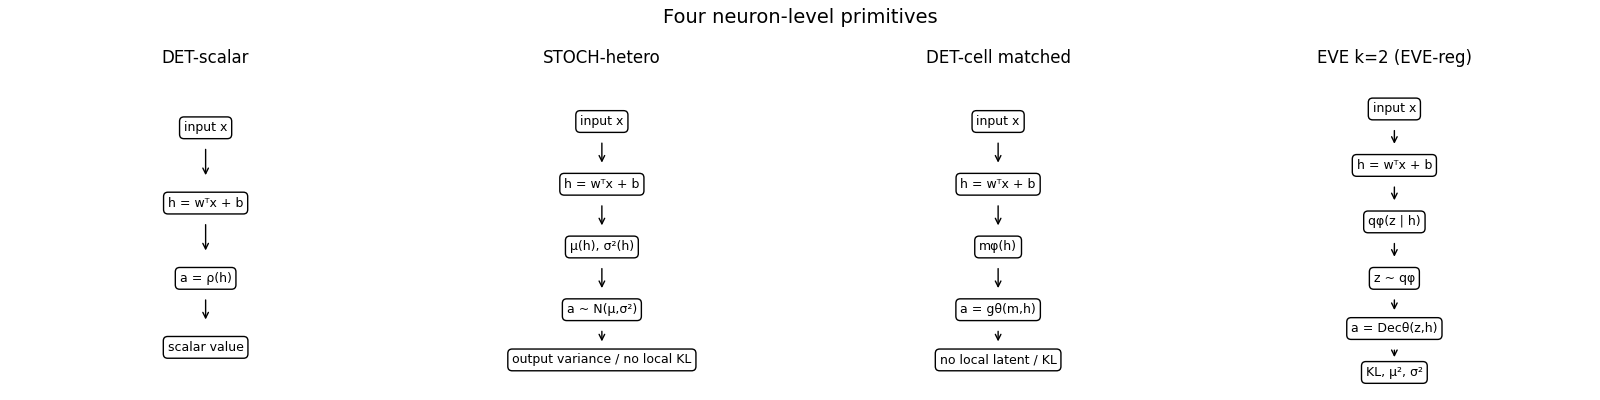

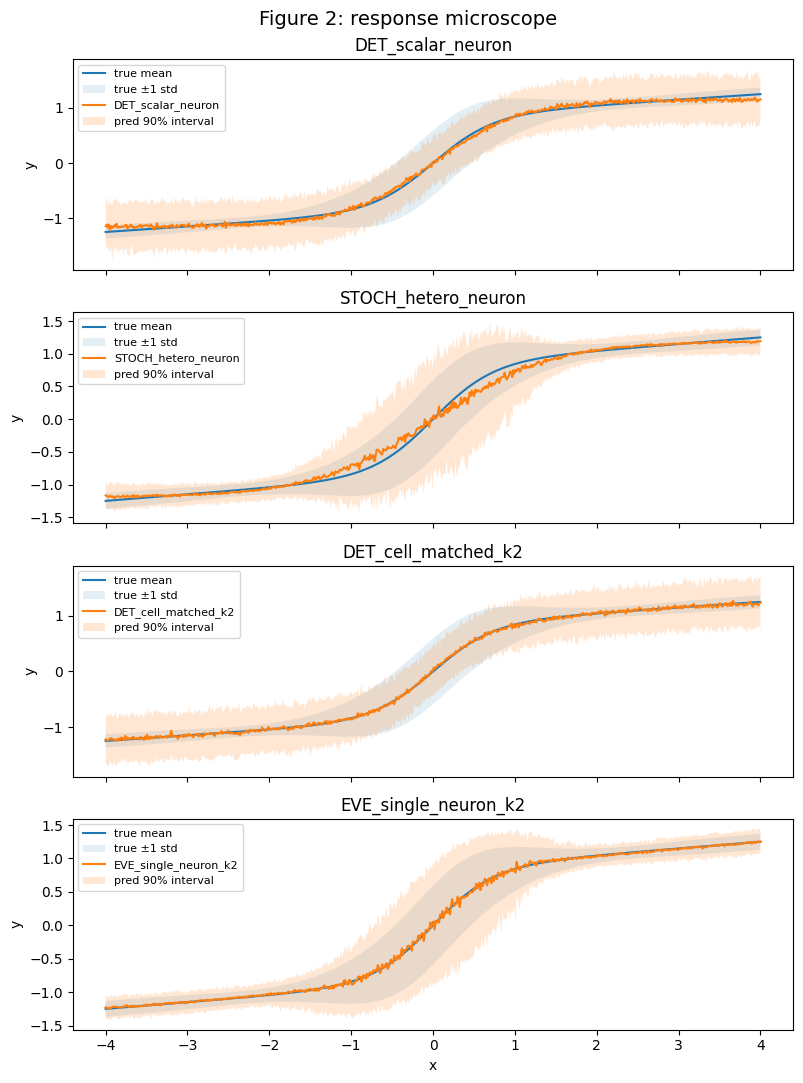

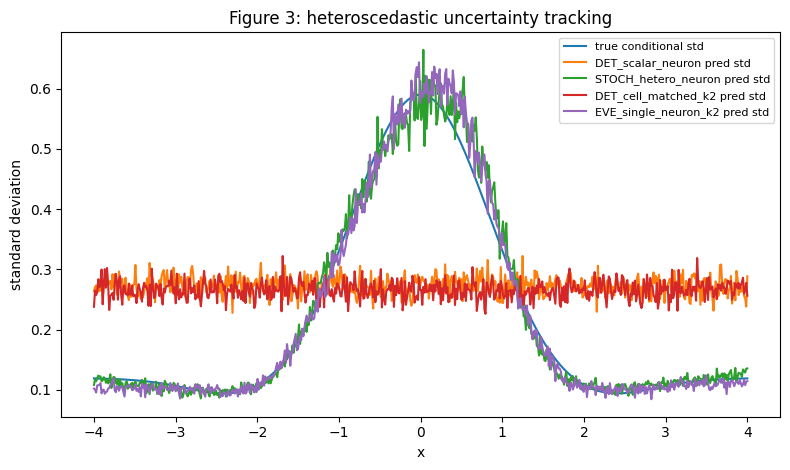

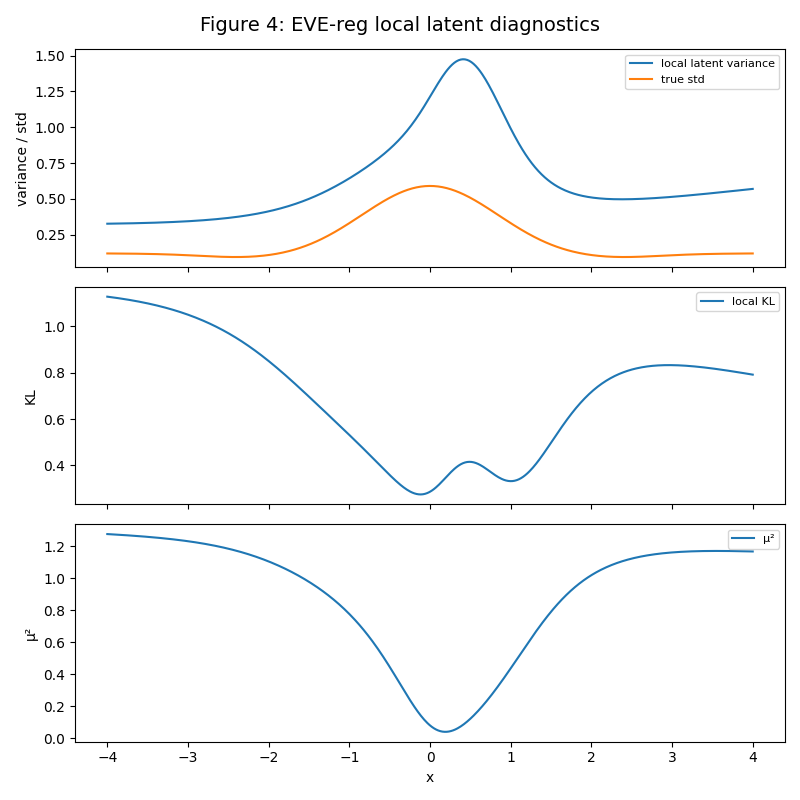

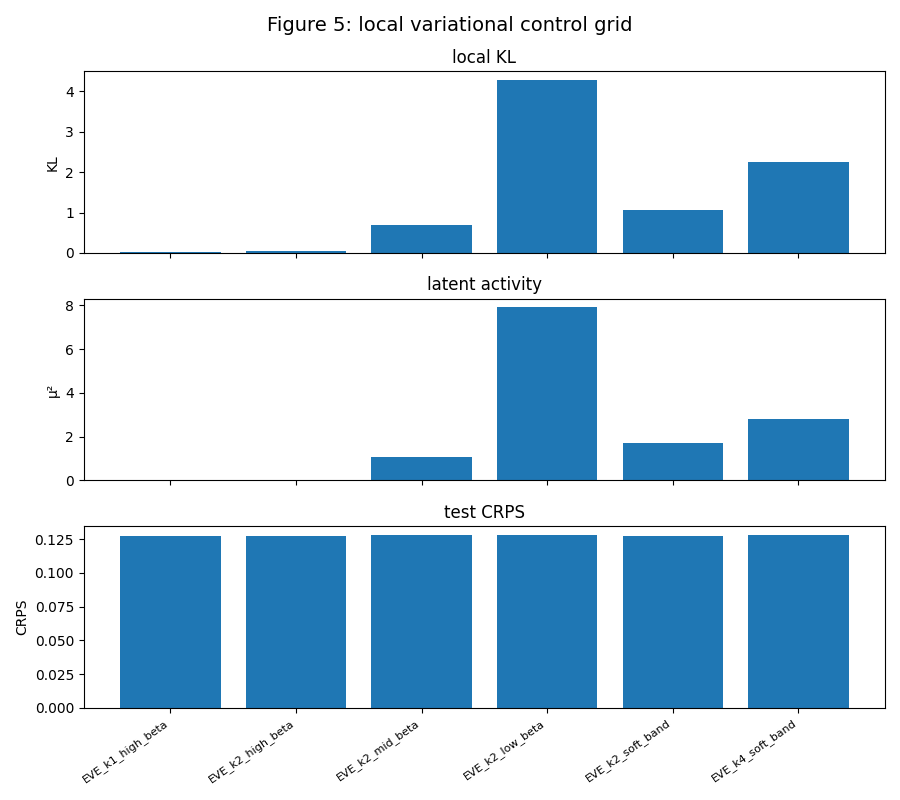

In [9]:

# ============================================================
# 8. Figures 1-5
# ============================================================

def draw_box(ax, xy, text, fontsize=9):
    x, y = xy
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", lw=1.0))


def arrow(ax, start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.0))

# Figure 1: anatomy.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, title in zip(axes, ["DET-scalar", "STOCH-hetero", "DET-cell matched", "EVE k=2 (EVE-reg)"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

ax = axes[0]
draw_box(ax, (0.5, 0.82), "input x")
draw_box(ax, (0.5, 0.58), "h = wᵀx + b")
draw_box(ax, (0.5, 0.34), "a = ρ(h)")
draw_box(ax, (0.5, 0.12), "scalar value")
arrow(ax, (0.5, 0.76), (0.5, 0.66)); arrow(ax, (0.5, 0.52), (0.5, 0.42)); arrow(ax, (0.5, 0.28), (0.5, 0.20))

ax = axes[1]
draw_box(ax, (0.5, 0.84), "input x")
draw_box(ax, (0.5, 0.64), "h = wᵀx + b")
draw_box(ax, (0.5, 0.44), "μ(h), σ²(h)")
draw_box(ax, (0.5, 0.24), "a ~ N(μ,σ²)")
draw_box(ax, (0.5, 0.08), "output variance / no local KL")
arrow(ax, (0.5, 0.78), (0.5, 0.70)); arrow(ax, (0.5, 0.58), (0.5, 0.50)); arrow(ax, (0.5, 0.38), (0.5, 0.30)); arrow(ax, (0.5, 0.18), (0.5, 0.13))

ax = axes[2]
draw_box(ax, (0.5, 0.84), "input x")
draw_box(ax, (0.5, 0.64), "h = wᵀx + b")
draw_box(ax, (0.5, 0.44), "mφ(h)")
draw_box(ax, (0.5, 0.24), "a = gθ(m,h)")
draw_box(ax, (0.5, 0.08), "no latent/KL")
arrow(ax, (0.5, 0.78), (0.5, 0.70)); arrow(ax, (0.5, 0.58), (0.5, 0.50)); arrow(ax, (0.5, 0.38), (0.5, 0.30)); arrow(ax, (0.5, 0.18), (0.5, 0.13))

ax = axes[3]
draw_box(ax, (0.5, 0.88), "input x")
draw_box(ax, (0.5, 0.70), "h = wᵀx + b")
draw_box(ax, (0.5, 0.52), "qφ(z | h)")
draw_box(ax, (0.5, 0.34), "z ~ qφ")
draw_box(ax, (0.5, 0.18), "a = Decθ(z,h)")
draw_box(ax, (0.5, 0.04), "KL, μ², σ²")
arrow(ax, (0.5, 0.82), (0.5, 0.76)); arrow(ax, (0.5, 0.64), (0.5, 0.58)); arrow(ax, (0.5, 0.46), (0.5, 0.40)); arrow(ax, (0.5, 0.28), (0.5, 0.23)); arrow(ax, (0.5, 0.12), (0.5, 0.08))

fig.suptitle("Four neuron-level primitives", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_primitive_anatomy.png", dpi=260)
plt.show()

# Figure 2: response microscope.
model_order = ["DET_scalar_neuron", "STOCH_hetero_neuron", "DET_cell_matched_k2", "EVE_single_neuron_k2"]
fig, axes = plt.subplots(len(model_order), 1, figsize=(8, 11), sharex=True)
for ax, name in zip(axes, model_order):
    model = rep_models[name]
    gdf = grid_predictions(model, x_grid, mc=MC_EVAL)
    ax.plot(truth_grid_df["x"], truth_grid_df["true_mean"], label="true mean")
    ax.fill_between(truth_grid_df["x"],
                    truth_grid_df["true_mean"] - truth_grid_df["true_std"],
                    truth_grid_df["true_mean"] + truth_grid_df["true_std"],
                    alpha=0.12, label="true ±1 std")
    ax.plot(gdf["x"], gdf["pred_mean"], label=name)
    ax.fill_between(gdf["x"], gdf["pred_lo90"], gdf["pred_hi90"], alpha=0.18, label="pred 90% interval")
    ax.set_title(name)
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
axes[-1].set_xlabel("x")
fig.suptitle("Figure 2: response microscope", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_response_microscope.png", dpi=260)
plt.show()

# Figure 3: heteroscedastic uncertainty tracking.
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(truth_grid_df["x"], truth_grid_df["true_std"], label="true conditional std")
for name in model_order:
    gdf = grid_predictions(rep_models[name], x_grid, mc=MC_EVAL)
    ax.plot(gdf["x"], gdf["pred_std"], label=f"{name} pred std")
ax.set_title("Figure 3: heteroscedastic uncertainty tracking")
ax.set_xlabel("x")
ax.set_ylabel("standard deviation")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_heteroscedastic_uncertainty_tracking.png", dpi=260)
plt.show()

# Figure 4: EVE latent diagnostics.
eve_rep = rep_models["EVE_single_neuron_k2"]
eve_diag = eve_latent_grid(eve_rep, x_grid)
eve_diag.to_csv(DIAG_DIR / "representative_EVE_single_neuron_k2_grid_latent_diagnostics.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].plot(eve_diag["x"], eve_diag["sigma2_mean"], label="local latent variance")
axes[0].plot(truth_grid_df["x"], truth_grid_df["true_std"], label="true std")
axes[0].set_ylabel("variance / std")
axes[0].legend(fontsize=8)
axes[1].plot(eve_diag["x"], eve_diag["kl"], label="local KL")
axes[1].set_ylabel("KL")
axes[1].legend(fontsize=8)
axes[2].plot(eve_diag["x"], eve_diag["mu2"], label="μ²")
axes[2].set_xlabel("x")
axes[2].set_ylabel("μ²")
axes[2].legend(fontsize=8)
fig.suptitle("Figure 4: EVE-reg local latent diagnostics", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_eve_latent_diagnostics.png", dpi=260)
plt.show()

# Figure 5: local variational control grid.
if len(control_df) > 0:
    order = [cfg.name for cfg in control_configs]
    cplot = control_df.groupby("model", as_index=False).agg({"eve_kl_mean": "mean", "eve_mu2_mean": "mean", "crps": "mean"})
    cplot["model"] = pd.Categorical(cplot["model"], categories=order, ordered=True)
    cplot = cplot.sort_values("model")
    xpos = np.arange(len(cplot))

    fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    axes[0].bar(xpos, cplot["eve_kl_mean"])
    axes[0].set_ylabel("KL")
    axes[0].set_title("local KL")
    axes[1].bar(xpos, cplot["eve_mu2_mean"])
    axes[1].set_ylabel("μ²")
    axes[1].set_title("latent activity")
    axes[2].bar(xpos, cplot["crps"])
    axes[2].set_ylabel("CRPS")
    axes[2].set_title("test CRPS")
    axes[2].set_xticks(xpos)
    axes[2].set_xticklabels(cplot["model"].astype(str), rotation=35, ha="right", fontsize=8)
    fig.suptitle("Figure 5: local variational control grid", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig05_local_variational_control_grid.png", dpi=260)
    plt.show()


## 9. PyTorch integration smoke test

This is not a performance benchmark. It shows that EVE can be implemented as a standard `nn.Module`, inserted into a square PyTorch MLP, trained with Adam and inspected through diagnostics.


In [10]:

# ============================================================
# 9. PyTorch integration smoke test
# ============================================================

class EVELocalActivation(nn.Module):
    """Vectorized EVE activation layer for a standard PyTorch MLP."""
    def __init__(self, k: int = 2, hidden: int = 16):
        super().__init__()
        self.k = int(k)
        self.encoder = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, 2 * self.k),
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.k + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, h: torch.Tensor, mc: int = 1, sample: bool = True) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        B, W = h.shape
        flat = h.reshape(B * W, 1)
        stats = self.encoder(flat)
        mu, raw_logvar = stats.chunk(2, dim=-1)
        logvar = torch.clamp(raw_logvar, min=-7.0, max=3.0)
        sigma2 = torch.exp(logvar)
        kl = 0.5 * torch.sum(mu.pow(2) + sigma2 - logvar - 1.0, dim=-1, keepdim=True)

        if sample:
            eps = torch.randn(mc, B * W, self.k, device=h.device)
            z = mu.unsqueeze(0) + torch.sqrt(sigma2).unsqueeze(0) * eps
        else:
            z = mu.unsqueeze(0).expand(mc, -1, -1)

        flat_h = flat.unsqueeze(0).expand(mc, B * W, 1)
        dec_in = torch.cat([z, flat_h], dim=-1)
        out = self.decoder(dec_in.reshape(mc * B * W, self.k + 1)).reshape(mc, B, W)
        if mc == 1:
            out = out.squeeze(0)

        diagnostics = {
            "kl": kl.reshape(B, W).mean(),
            "mu2": mu.pow(2).sum(dim=-1).reshape(B, W).mean(),
            "sigma2": sigma2.mean(),
        }
        return out, diagnostics


class EVESquareMLP(nn.Module):
    def __init__(self, width: int = 16, depth: int = 3, k: int = 2, hidden: int = 16):
        super().__init__()
        self.width = int(width)
        self.depth = int(depth)
        self.input = nn.Linear(1, width)
        self.layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth - 1)])
        self.eve = EVELocalActivation(k=k, hidden=hidden)
        self.output = nn.Linear(width, 1)
        self.raw_obs = nn.Parameter(torch.tensor([-2.0], dtype=torch.float32))

    def obs_var(self) -> torch.Tensor:
        return F.softplus(self.raw_obs).pow(2) + 1e-6

    def forward(self, x: torch.Tensor, mc: int = 1, sample: bool = True) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        h = self.input(x)
        total = {"kl": 0.0, "mu2": 0.0, "sigma2": 0.0}
        h, diag = self.eve(h, mc=1, sample=sample)
        for key in total:
            total[key] = total[key] + diag[key]
        for layer in self.layers:
            h = layer(h)
            h, diag = self.eve(h, mc=1, sample=sample)
            for key in total:
                total[key] = total[key] + diag[key]
        out = self.output(h)
        for key in total:
            total[key] = total[key] / self.depth
        return out, total

    def loss(self, x: torch.Tensor, y: torch.Tensor, beta: float = 1e-4) -> torch.Tensor:
        pred, diag = self.forward(x, sample=True)
        var = self.obs_var().expand_as(pred)
        return gaussian_nll(y, pred, var) + beta * diag["kl"]

    @torch.no_grad()
    def predictive_samples(self, x: torch.Tensor, mc: int = 96, include_obs: bool = True) -> torch.Tensor:
        outs = []
        for _ in range(mc):
            pred, _ = self.forward(x, sample=True)
            if include_obs:
                pred = pred + torch.randn_like(pred) * torch.sqrt(self.obs_var())
            outs.append(pred)
        return torch.stack(outs, dim=0)


pytorch_summary = {}
if RUN_PYTORCH_INTEGRATION:
    seed_all(90_000 + SEEDS[0])
    eve_square = EVESquareMLP(width=16, depth=3, k=2, hidden=16).to(DEVICE)
    opt = torch.optim.Adam(eve_square.parameters(), lr=LR)
    x_train, y_train = rep_data["train"]["x"], rep_data["train"]["y"]
    x_val, y_val = rep_data["val"]["x"], rep_data["val"]["y"]
    hist = []
    best_state = copy.deepcopy(eve_square.state_dict())
    best_val = float("inf")

    for epoch in range(1, EPOCHS_MLP + 1):
        eve_square.train()
        opt.zero_grad(set_to_none=True)
        loss = eve_square.loss(x_train, y_train, beta=1e-4)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(eve_square.parameters(), max_norm=5.0)
        opt.step()

        if epoch == 1 or epoch % 25 == 0 or epoch == EPOCHS_MLP:
            eve_square.eval()
            with torch.no_grad():
                val_loss = eve_square.loss(x_val, y_val, beta=1e-4)
            if to_float(val_loss) < best_val:
                best_val = to_float(val_loss)
                best_state = copy.deepcopy(eve_square.state_dict())
            hist.append({"epoch": epoch, "train_loss": to_float(loss), "val_loss": to_float(val_loss)})

    eve_square.load_state_dict(best_state)
    hist_df = pd.DataFrame(hist)
    hist_df.to_csv(HIST_DIR / "pytorch_integration_square_mlp_history.csv", index=False)

    with torch.no_grad():
        dummy_x = torch.zeros(8, 1, device=DEVICE)
        dummy_y, dummy_diag = eve_square(dummy_x, sample=True)
        test_samples = eve_square.predictive_samples(rep_data["test"]["x"], mc=MC_EVAL, include_obs=True)
        test_mean = test_samples.mean(dim=0)
        test_var = test_samples.var(dim=0, unbiased=False) + 1e-6
        test_row = {
            "mse": to_float(F.mse_loss(test_mean, rep_data["test"]["y"])),
            "nll": to_float(gaussian_nll(rep_data["test"]["y"], test_mean, test_var)),
            "crps": to_float(crps_ensemble(test_samples, rep_data["test"]["y"])),
        }

    pytorch_summary = {
        "module": "EVESquareMLP",
        "width": 16,
        "depth": 3,
        "latent_k": 2,
        "parameter_count": int(sum(p.numel() for p in eve_square.parameters() if p.requires_grad)),
        "input_shape": list(dummy_x.shape),
        "output_shape": list(dummy_y.shape),
        "diagnostics_available": list(dummy_diag.keys()),
        "final_best_val_loss": best_val,
        "test_metrics": test_row,
    }

    pd.DataFrame([pytorch_summary | {"test_mse": test_row["mse"], "test_nll": test_row["nll"], "test_crps": test_row["crps"]}]).to_csv(TABLE_DIR / "pytorch_integration_smoke_test.csv", index=False)
    with open(TABLE_DIR / "pytorch_integration_summary.json", "w") as f:
        json.dump(pytorch_summary, f, indent=2)
    torch.save(eve_square.state_dict(), MODEL_DIR / "EVE_square_MLP_state_dict.pt")

    print("PyTorch integration summary:")
    print(json.dumps(pytorch_summary, indent=2))


PyTorch integration summary:
{
  "module": "EVESquareMLP",
  "width": 16,
  "depth": 3,
  "latent_k": 2,
  "parameter_count": 775,
  "input_shape": [
    8,
    1
  ],
  "output_shape": [
    8,
    1
  ],
  "diagnostics_available": [
    "kl",
    "mu2",
    "sigma2"
  ],
  "final_best_val_loss": 0.15131153166294098,
  "test_metrics": {
    "mse": 0.07171641290187836,
    "nll": 0.15361671149730682,
    "crps": 0.13547274470329285
  }
}


## 10. Figure 6: corrected PyTorch integration plot

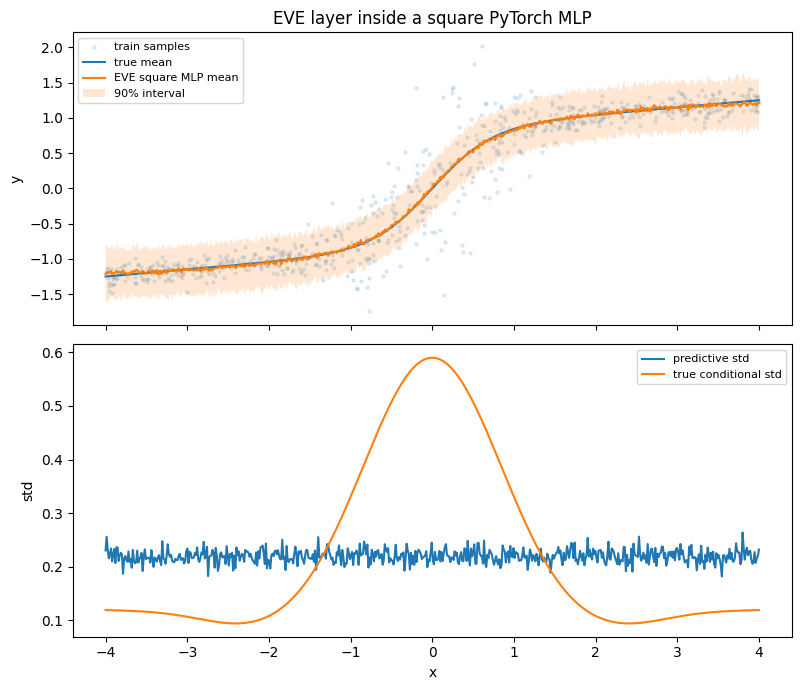

In [11]:

# ============================================================
# 10. Figure 6: corrected PyTorch integration plot
# ============================================================

if RUN_PYTORCH_INTEGRATION and "eve_square" in globals():
    xg = torch.linspace(-4, 4, 600, device=DEVICE).view(-1, 1)
    with torch.no_grad():
        samples = eve_square.predictive_samples(xg, mc=160 if not FAST_MODE else 96, include_obs=True)
        mean = samples.mean(dim=0)
        lo = torch.quantile(samples, 0.05, dim=0)
        hi = torch.quantile(samples, 0.95, dim=0)
        std = samples.std(dim=0, unbiased=False)

    xg_np = cpu_np(xg).ravel()
    order = np.argsort(xg_np)
    xg_np = xg_np[order]
    mean_np = cpu_np(mean).ravel()[order]
    lo_np = cpu_np(lo).ravel()[order]
    hi_np = cpu_np(hi).ravel()[order]
    std_np = cpu_np(std).ravel()[order]

    square_grid_df = pd.DataFrame({
        "x": xg_np,
        "pred_mean": mean_np,
        "pred_lo90": lo_np,
        "pred_hi90": hi_np,
        "pred_std": std_np,
    })
    square_grid_df.to_csv(PRED_DIR / "EVE_square_MLP_grid_predictions.csv", index=False)

    # Deterministic subset for a clean plot.
    rng = np.random.default_rng(123)
    idx = rng.choice(rep_data["train"]["x"].shape[0], size=min(700, rep_data["train"]["x"].shape[0]), replace=False)
    x_scatter = cpu_np(rep_data["train"]["x"])[idx].ravel()
    y_scatter = cpu_np(rep_data["train"]["y"])[idx].ravel()

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axes[0].scatter(x_scatter, y_scatter, s=5, alpha=0.12, label="train samples")
    axes[0].plot(truth_grid_df["x"], truth_grid_df["true_mean"], label="true mean")
    axes[0].plot(xg_np, mean_np, label="EVE square MLP mean")
    axes[0].fill_between(xg_np, lo_np, hi_np, alpha=0.18, label="90% interval")
    axes[0].set_title("EVE layer inside a square PyTorch MLP")
    axes[0].set_ylabel("y")
    axes[0].legend(fontsize=8)

    axes[1].plot(xg_np, std_np, label="predictive std")
    axes[1].plot(truth_grid_df["x"], truth_grid_df["true_std"], label="true conditional std")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("std")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig06_pytorch_eve_square_mlp_integration.png", dpi=260)
    plt.show()


## 11. Computational cost snapshot

This is intentionally descriptive. It situates EVE's overhead without turning the paper into a systems benchmark.


Computational cost snapshot:


,object,parameter_count,state_size_mb,forward_one_ms,forward_mc_ms,train_step_ms,cuda_peak_memory_mb,forward_mc_ratio_vs_det
0,DET_scalar,5,0.000019,0.409769,0.437027,2.678588,19.743652,1.000000
1,STOCH_hetero,1158,0.004417,0.687252,0.853777,4.320327,19.775879,1.953601
2,DET_cell_matched_k2,2536,0.009674,0.753744,0.758083,4.164720,19.924316,1.734635
3,EVE_k2,2472,0.009430,1.188425,1.173206,6.121330,28.129883,2.684513
4,EVE_square_MLP,775,0.002956,3.432805,203.726557,7.891270,24.929199,466.164265


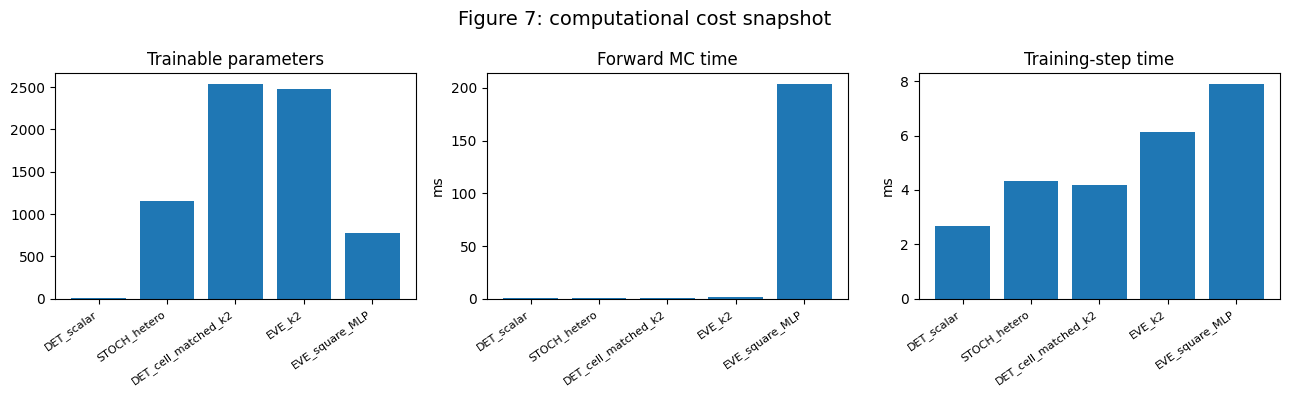

In [12]:

# ============================================================
# 11. Computational cost snapshot
# ============================================================

if RUN_COMPUTE_COST:
    def _sync():
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    def _param_count(model):
        return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

    def _state_size_mb(model):
        total = 0
        for tensor in model.state_dict().values():
            if torch.is_tensor(tensor):
                total += tensor.numel() * tensor.element_size()
        return total / (1024 ** 2)

    def _benchmark_call(fn, warmup=3, repeats=TIMING_REPEATS):
        for _ in range(warmup):
            _ = fn()
        _sync()
        t0 = time.perf_counter()
        for _ in range(repeats):
            _ = fn()
        _sync()
        return 1000.0 * (time.perf_counter() - t0) / repeats

    def _train_step_time(model, name, x, y, repeats=TIMING_REPEATS):
        m = copy.deepcopy(model).to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=LR)
        def step():
            opt.zero_grad(set_to_none=True)
            if isinstance(m, EVENeuron):
                loss = m.loss(x, y, mc=MC_TRAIN, beta=1e-3, lambda_band=0.05)
            elif isinstance(m, EVESquareMLP):
                loss = m.loss(x, y, beta=1e-4)
            else:
                loss = m.loss(x, y, mc=MC_TRAIN)
            loss.backward()
            opt.step()
            return loss
        return _benchmark_call(step, warmup=2, repeats=max(3, repeats // 2))

    x_bench = rep_data["train"]["x"][:512]
    y_bench = rep_data["train"]["y"][:512]
    cost_objects = [
        ("DET_scalar", rep_models["DET_scalar_neuron"]),
        ("STOCH_hetero", rep_models["STOCH_hetero_neuron"]),
        ("DET_cell_matched_k2", rep_models["DET_cell_matched_k2"]),
        ("EVE_k2", rep_models["EVE_single_neuron_k2"]),
    ]
    if RUN_PYTORCH_INTEGRATION and "eve_square" in globals():
        cost_objects.append(("EVE_square_MLP", eve_square))

    cost_rows = []
    for label, model in cost_objects:
        model = model.to(DEVICE).eval()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        if isinstance(model, EVESquareMLP):
            fwd_one = _benchmark_call(lambda: model.predictive_samples(x_bench, mc=1, include_obs=True))
            fwd_mc = _benchmark_call(lambda: model.predictive_samples(x_bench, mc=32 if FAST_MODE else 64, include_obs=True))
        else:
            fwd_one = _benchmark_call(lambda: model.predictive_samples(x_bench, mc=1, include_obs=True))
            fwd_mc = _benchmark_call(lambda: model.predictive_samples(x_bench, mc=32 if FAST_MODE else 64, include_obs=True))

        train_step = _train_step_time(model, label, x_bench, y_bench)
        peak_mb = None
        if torch.cuda.is_available():
            peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

        cost_rows.append({
            "object": label,
            "parameter_count": _param_count(model),
            "state_size_mb": _state_size_mb(model),
            "forward_one_ms": fwd_one,
            "forward_mc_ms": fwd_mc,
            "train_step_ms": train_step,
            "cuda_peak_memory_mb": peak_mb,
        })

    cost_df = pd.DataFrame(cost_rows)
    det_ref = float(cost_df.loc[cost_df["object"] == "DET_scalar", "forward_mc_ms"].iloc[0])
    cost_df["forward_mc_ratio_vs_det"] = cost_df["forward_mc_ms"] / max(det_ref, 1e-9)
    cost_df.to_csv(TABLE_DIR / "computational_cost_snapshot.csv", index=False)
    with open(TABLE_DIR / "computational_cost_summary.json", "w") as f:
        json.dump(cost_df.to_dict(orient="records"), f, indent=2)

    print("Computational cost snapshot:")
    display(cost_df)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    labels = cost_df["object"].tolist()
    xpos = np.arange(len(labels))
    axes[0].bar(xpos, cost_df["parameter_count"].values)
    axes[0].set_title("Trainable parameters")
    axes[1].bar(xpos, cost_df["forward_mc_ms"].values)
    axes[1].set_title("Forward MC time")
    axes[1].set_ylabel("ms")
    axes[2].bar(xpos, cost_df["train_step_ms"].values)
    axes[2].set_title("Training-step time")
    axes[2].set_ylabel("ms")
    for ax in axes:
        ax.set_xticks(xpos)
        ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    fig.suptitle("Figure 7: computational cost snapshot", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig07_computational_cost_snapshot.png", dpi=260)
    plt.show()


## 12. Save raw data, predictions, tables and manifest

In [13]:

# ============================================================
# 12. Save raw data, predictions, summary tables, manifest
# ============================================================

# Save representative datasets and all seed datasets.
def save_split(seed: int, split_name: str, data: Dict[str, torch.Tensor]) -> None:
    df = pd.DataFrame({
        "x": cpu_np(data["x"]).ravel(),
        "y": cpu_np(data["y"]).ravel(),
        "true_mean": cpu_np(data["true_mean"]).ravel(),
        "true_std": cpu_np(data["true_std"]).ravel(),
        "ambiguity": cpu_np(data["ambiguity"]).ravel(),
    })
    df.to_csv(DATA_DIR / f"seed{seed}_{split_name}_data.csv", index=False)
    np.savez_compressed(
        DATA_DIR / f"seed{seed}_{split_name}_data.npz",
        x=cpu_np(data["x"]),
        y=cpu_np(data["y"]),
        true_mean=cpu_np(data["true_mean"]),
        true_std=cpu_np(data["true_std"]),
        ambiguity=cpu_np(data["ambiguity"]),
    )

for seed in SEEDS:
    splits = make_data_splits(seed)
    for split_name, split_data in splits.items():
        save_split(seed, split_name, split_data)

# Save compact prediction samples for representative seed only.
for name, model in rep_models.items():
    for split_name, split_data in rep_data.items():
        with torch.no_grad():
            samples = model.predictive_samples(split_data["x"], mc=min(MC_EVAL, 128), include_obs=True)
            mean = samples.mean(dim=0)
            std = samples.std(dim=0, unbiased=False)
            lo = torch.quantile(samples, 0.05, dim=0)
            hi = torch.quantile(samples, 0.95, dim=0)
        pred_df = pd.DataFrame({
            "x": cpu_np(split_data["x"]).ravel(),
            "y": cpu_np(split_data["y"]).ravel(),
            "true_mean": cpu_np(split_data["true_mean"]).ravel(),
            "true_std": cpu_np(split_data["true_std"]).ravel(),
            "ambiguity": cpu_np(split_data["ambiguity"]).ravel(),
            "pred_mean": cpu_np(mean).ravel(),
            "pred_std": cpu_np(std).ravel(),
            "pred_lo90": cpu_np(lo).ravel(),
            "pred_hi90": cpu_np(hi).ravel(),
        })
        pred_df.to_csv(PRED_DIR / f"representative_{name}_{split_name}_predictions.csv", index=False)
        np.savez_compressed(
            PRED_DIR / f"representative_{name}_{split_name}_prediction_samples.npz",
            pred_samples=cpu_np(samples),
            pred_mean=cpu_np(mean),
            pred_std=cpu_np(std),
            pred_lo90=cpu_np(lo),
            pred_hi90=cpu_np(hi),
        )

# Primitive positioning table for paper.
primitive_positioning = pd.DataFrame([
    {"primitive": "DET-scalar", "output": "scalar value", "uncertainty_lives": "none", "posterior_semantics": "none", "reference_distribution": "none", "local_KL": "no", "main_diagnostic": "activation"},
    {"primitive": "STOCH-hetero", "output": "Gaussian predictive sample", "uncertainty_lives": "input-dependent output variance", "posterior_semantics": "none", "reference_distribution": "none", "local_KL": "no", "main_diagnostic": "predictive variance"},
    {"primitive": "DET-cell matched", "output": "deterministic decoded value", "uncertainty_lives": "none beyond global observation variance", "posterior_semantics": "none", "reference_distribution": "none", "local_KL": "no", "main_diagnostic": "deterministic code activity"},
    {"primitive": "BNN", "output": "scalar under sampled weights", "uncertainty_lives": "weights", "posterior_semantics": "weight posterior; not unit-local", "reference_distribution": "weight prior; not unit-local", "local_KL": "no at unit state", "main_diagnostic": "weight uncertainty"},
    {"primitive": "Dropout", "output": "masked value", "uncertainty_lives": "mask", "posterior_semantics": "depends on declared interpretation", "reference_distribution": "none or implicit, depending on interpretation", "local_KL": "no local unit KL", "main_diagnostic": "masked activation"},
    {"primitive": "VAE latent unit", "output": "decoder-level latent effect", "uncertainty_lives": "example/model latent", "posterior_semantics": "posterior over example/model latent", "reference_distribution": "latent prior", "local_KL": "global or layer-level", "main_diagnostic": "latent representation"},
    {"primitive": "EVE-reg", "output": "decoded local latent activation", "uncertainty_lives": "internal latent variability", "posterior_semantics": "no strict local posterior claim", "reference_distribution": "standard-normal local reference", "local_KL": "yes", "main_diagnostic": "KL, mu2, sigma2, entropy, MI"},
])
primitive_positioning.to_csv(TABLE_DIR / "primitive_positioning_table.csv", index=False)

manifest = {
    "experiment": "EVE single-neuron microscope multiseed",
    "main_claim": "The controlled experiment compares an EVE-reg unit with DET-scalar, STOCH-hetero and DET-cell matched baselines. EVE-reg exposes an input-conditioned local latent distribution, a local reference penalty, and unit-indexed diagnostics without claiming strict local posterior inference.",
    "fast_mode": FAST_MODE,
    "num_seeds": N_SEEDS,
    "seeds": SEEDS,
    "device": str(DEVICE),
    "config": CONFIG,
    "core_outputs": {
        "main_metrics_by_seed": "tables/main_metrics_by_seed.csv",
        "main_metrics_mean_std": "tables/main_metrics_mean_std.csv",
        "uncertainty_tracking_mean_std": "tables/uncertainty_tracking_mean_std.csv",
        "latent_diagnostics_mean_std": "tables/latent_diagnostics_mean_std.csv",
        "control_grid_mean_std": "tables/control_grid_mean_std.csv",
        "computational_cost_snapshot": "tables/computational_cost_snapshot.csv",
        "pytorch_integration_summary": "tables/pytorch_integration_summary.json",
    },
    "saved_files": [str(p.relative_to(OUT_DIR)) for p in sorted(OUT_DIR.rglob("*")) if p.is_file()],
}
with open(OUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest and reproducibility files.")
print("Output files so far:", len(manifest["saved_files"]))


Saved manifest and reproducibility files.
Output files so far: 207


## 13. Required-file check and final zip export

This final cell prevents incomplete exports. If a required file is missing, the notebook stops before creating the final zip.


In [14]:

# ============================================================
# 13. Required-file check and zip export
# ============================================================

required_files = [
    "figures/fig01_primitive_anatomy.png",
    "figures/fig02_response_microscope.png",
    "figures/fig03_heteroscedastic_uncertainty_tracking.png",
    "figures/fig04_eve_latent_diagnostics.png",
    "figures/fig05_local_variational_control_grid.png",
    "figures/fig06_pytorch_eve_square_mlp_integration.png",
    "figures/fig07_computational_cost_snapshot.png",
    "tables/main_metrics_by_seed.csv",
    "tables/main_metrics_mean_std.csv",
    "tables/paper_test_summary_mean_std.csv",
    "tables/uncertainty_tracking_by_seed.csv",
    "tables/uncertainty_tracking_mean_std.csv",
    "tables/latent_diagnostics_by_seed.csv",
    "tables/latent_diagnostics_mean_std.csv",
    "tables/control_grid_by_seed.csv",
    "tables/control_grid_mean_std.csv",
    "tables/pytorch_integration_smoke_test.csv",
    "tables/pytorch_integration_summary.json",
    "tables/computational_cost_snapshot.csv",
    "tables/computational_cost_summary.json",
    "tables/primitive_positioning_table.csv",
    "data/truth_grid.csv",
    "manifest.json",
]

missing = [rel for rel in required_files if not (OUT_DIR / rel).exists()]
assert not missing, "Missing required files before zip export:\n" + "\n".join(missing)

zip_path = OUT_DIR / "eve_single_neuron_outputs_publication_multiseed.zip"
if zip_path.exists():
    zip_path.unlink()

# Refresh manifest with final file list before zipping.
with open(OUT_DIR / "manifest.json", "r") as f:
    manifest = json.load(f)
manifest["saved_files"] = [str(p.relative_to(OUT_DIR)) for p in sorted(OUT_DIR.rglob("*")) if p.is_file() and p.name != zip_path.name]
with open(OUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in OUT_DIR.rglob("*"):
        if file.is_file() and file.name != zip_path.name:
            zf.write(file, arcname=file.relative_to(OUT_DIR))

print("Exported:", zip_path.resolve())
print("Required files checked:", len(required_files))
print("Total files in zip:", len(manifest["saved_files"]))

# Display the most important tables at the end.
print("\nPaper test summary mean/std:")
display(pd.read_csv(TABLE_DIR / "paper_test_summary_mean_std.csv"))
print("\nUncertainty tracking mean/std:")
display(pd.read_csv(TABLE_DIR / "uncertainty_tracking_mean_std.csv"))
print("\nLatent diagnostics mean/std:")
display(pd.read_csv(TABLE_DIR / "latent_diagnostics_mean_std.csv"))
print("\nComputational cost snapshot:")
display(pd.read_csv(TABLE_DIR / "computational_cost_snapshot.csv"))


Exported: /content/eve_single_neuron_outputs_publication/eve_single_neuron_outputs_publication_multiseed.zip
Required files checked: 23
Total files in zip: 208

Paper test summary mean/std:


,model,split,mse_mean,mse_std,nll_mean,nll_std,crps_mean,crps_std,coverage90_mean,coverage90_std,...,detcell_has_local_kl_mean,detcell_has_local_kl_std,eve_kl_mean_mean,eve_kl_mean_std,eve_mu2_mean_mean,eve_mu2_mean_std,eve_sigma2_mean_mean,eve_sigma2_mean_std,eve_obs_var_mean,eve_obs_var_std
0,DET_cell_matched_k2,test,0.077576,0.006448,0.146075,0.045869,0.142542,0.004403,0.895067,0.010161,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DET_scalar_neuron,test,0.079312,0.006411,0.159317,0.048927,0.144838,0.004502,0.896267,0.009895,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EVE_single_neuron_k2,test,0.077647,0.006077,-0.301380,0.032620,0.127612,0.003995,0.885600,0.008227,...,NaN,NaN,0.968528,0.214557,1.207209,0.348405,0.681714,0.215873,0.010106,0.000555
3,STOCH_hetero_neuron,test,0.081630,0.006215,-0.274771,0.034062,0.130264,0.004267,0.881867,0.008962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Uncertainty tracking mean/std:


,model,corr_pred_std_true_std_mean,corr_pred_std_true_std_std,pred_std_mean_grid_mean,pred_std_mean_grid_std
0,DET_cell_matched_k2,0.024365,0.033466,0.266166,0.005349
1,DET_scalar_neuron,-0.011229,0.028961,0.269995,0.007269
2,EVE_single_neuron_k2,0.994487,0.002394,0.226223,0.002181
3,STOCH_hetero_neuron,0.993331,0.001591,0.227122,0.002555



Latent diagnostics mean/std:


,model,corr_sigma2_true_std_mean,corr_sigma2_true_std_std,corr_kl_true_std_mean,corr_kl_true_std_std,corr_mu2_true_std_mean,corr_mu2_true_std_std,sigma2_mean_grid_mean,sigma2_mean_grid_std,kl_mean_grid_mean,kl_mean_grid_std,mu2_mean_grid_mean,mu2_mean_grid_std
0,EVE_single_neuron_k2,0.940653,0.035478,-0.778261,0.169529,-0.838138,0.073257,0.687551,0.219355,0.966331,0.208489,1.200214,0.340114



Computational cost snapshot:


,object,parameter_count,state_size_mb,forward_one_ms,forward_mc_ms,train_step_ms,cuda_peak_memory_mb,forward_mc_ratio_vs_det
0,DET_scalar,5,0.000019,0.409769,0.437027,2.678588,19.743652,1.000000
1,STOCH_hetero,1158,0.004417,0.687252,0.853777,4.320327,19.775879,1.953601
2,DET_cell_matched_k2,2536,0.009674,0.753744,0.758083,4.164720,19.924316,1.734635
3,EVE_k2,2472,0.009430,1.188425,1.173206,6.121330,28.129883,2.684513
4,EVE_square_MLP,775,0.002956,3.432805,203.726557,7.891270,24.929199,466.164265


## 14. Reproducibility outputs and scope

The publication package contains the following principal outputs:

- `fig01_primitive_anatomy.png`
- `fig02_response_microscope.png`
- `fig03_heteroscedastic_uncertainty_tracking.png`
- `fig04_eve_latent_diagnostics.png`
- `fig05_local_variational_control_grid.png`
- `fig06_pytorch_eve_square_mlp_integration.png`
- `fig07_computational_cost_snapshot.png`
- `main_metrics_mean_std.csv`
- `paper_test_summary_mean_std.csv`
- `uncertainty_tracking_mean_std.csv`
- `latent_diagnostics_mean_std.csv`
- `control_grid_mean_std.csv`
- `computational_cost_snapshot.csv`
- `primitive_positioning_table.csv`

The experiment is a controlled architectural illustration. It compares DET-scalar, STOCH-hetero, a deterministic capacity-matched cell, and an EVE-reg unit. The EVE-reg instance uses an input-conditioned local latent distribution, a standard-normal local reference distribution, and local KL regularization, without a strict local posterior claim. Latent variance and KL are reported as internal latent variability/activity unless additional uncertainty semantics are established. The benchmark does not establish general predictive superiority.
